# Route Choice Model Training Dataset 구축
> OTP K-best 경로 × 스마트카드 실제 통행 → OD별 선택 확률 데이터셋

**구조**: 각 행 = 1개 OD × 1개 대안경로
- **21개 경로 피처**: 시간, 거리, 환승, 요금, 모드 등
- **choice_prob (y)**: 해당 대안의 선택 확률 (= 매칭된 SC trip 수 / 전체 SC trip 수)
- 신규 수단(GTX 등) 도입 시, 경로 속성만 입력하면 선택 확률을 예측

In [ ]:
import pandas as pd
import numpy as np
import json
import csv
import os
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import ijson

import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

from module.route_features import (
    extract_itinerary_features, extract_trip_context, fix_missing_distances,
)
from module.similarity import (
    parse_otp_itinerary,
    parse_smartcard_trip,
    deduplicate_itineraries,
    compute_all_metrics,
    compute_composite_similarity,
)

In [ ]:
# === 설정 ===
OTP_INPUT_CSV = '../../data/otp/input/otp_od_input_over13.csv'
OTP_JSON_PATH = '../../data/otp/output/similarity.json'
TCN_DIR = '../../data/tcn'
OUTPUT_DIR = '../../data/training_set'

# 매칭 파라미터
SIMILARITY_THRESHOLD = 0.6   # 매칭 임계값 (미만이면 skip)
MIN_CHOICE_SET_SIZE = 2      # 최소 대안 수 (미만이면 OD 제외)

# 테스트 / 전체 실행
MAX_ODS = None  # None=전체, int=테스트용 OD 수 제한

# 체크포인트
CHECKPOINT_INTERVAL = 2000   # OD 단위

# GTFS (폴리라인 기반 공간 매칭)
USE_GTFS = False  # True: GTFS 기반 폴리라인 매칭 사용

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output: {OUTPUT_DIR}')
print(f'MAX_ODS: {MAX_ODS or "전체"}')

In [3]:
# === OTP 결과 로드 (SQLite 캐시 → 메모리 최소화) ===
# ★ 전체를 메모리에 올리지 않고, 매칭 시 필요한 OD만 DB에서 꺼내 씀
import gc
import pickle
import sqlite3

OTP_CACHE_DB = os.path.join(OUTPUT_DIR, 'otp_cache.db')
FORCE_REBUILD = False  # True: 캐시 무시하고 재생성

# --- 캐시 DB 존재 + JSON보다 최신 → 빌드 skip ---
CACHE_READY = False
if not FORCE_REBUILD and os.path.exists(OTP_CACHE_DB):
    if os.path.getmtime(OTP_CACHE_DB) >= os.path.getmtime(OTP_JSON_PATH):
        conn = sqlite3.connect(OTP_CACHE_DB)
        n_ods, n_itins = conn.execute(
            'SELECT COUNT(*), SUM(n_alts) FROM otp_cache').fetchone()
        conn.close()
        print(f'캐시 DB 확인: {n_ods:,} ODs, {n_itins:,} itineraries (메모리 사용 없음)')
        CACHE_READY = True
    else:
        print('JSON이 캐시보다 최신 → 재생성')

# --- 캐시 없으면 Single-pass 빌드 → SQLite 저장 ---
if not CACHE_READY:
    _gtfs_lookup = None

    # 1. CSV에서 id → od_pair 매핑
    od_map = {}
    with open(OTP_INPUT_CSV) as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader):
            od_map[i] = row['od_pair']
    print(f'CSV OD pairs: {len(od_map):,}')

    # 2. DB 초기화
    if os.path.exists(OTP_CACHE_DB):
        os.remove(OTP_CACHE_DB)
    conn = sqlite3.connect(OTP_CACHE_DB)
    conn.execute('PRAGMA journal_mode=WAL')
    conn.execute('''CREATE TABLE otp_cache (
        od_pair TEXT PRIMARY KEY,
        n_alts  INTEGER,
        data    BLOB
    )''')

    # 3. Single-pass 스트리밍 → DB 저장
    batch = []
    BATCH_SIZE = 2000
    loaded = 0
    skipped_empty = 0
    skipped_small = 0
    total_itins = 0

    with open(OTP_JSON_PATH, 'rb') as f:
        for item in tqdm(ijson.items(f, 'item', use_float=True),
                         desc='OTP 스트리밍+피처추출', total=len(od_map)):
            item_id = item.get('id')
            itins = item.get('data', {}).get('plan', {}).get('itineraries', [])
            if not itins:
                skipped_empty += 1
                continue

            od_pair = od_map.get(item_id)
            if od_pair is None:
                continue

            for itin in itins:
                fix_missing_distances(itin)

            deduped = deduplicate_itineraries(itins)
            if len(deduped) < MIN_CHOICE_SET_SIZE:
                skipped_small += 1
                continue

            parsed_list = []
            for itin in deduped:
                parsed = parse_otp_itinerary(itin, gtfs_lookup=_gtfs_lookup)
                if not USE_GTFS:
                    parsed.pop('route_polyline', None)
                    parsed.pop('shape_polyline', None)
                    parsed.pop('full_stop_coords', None)
                parsed_list.append(parsed)

            cache_entry = {
                'alt_features': [extract_itinerary_features(itin) for itin in deduped],
                'otp_parsed': parsed_list,
            }
            batch.append((od_pair, len(deduped),
                         pickle.dumps(cache_entry, protocol=pickle.HIGHEST_PROTOCOL)))
            total_itins += len(deduped)
            loaded += 1

            if len(batch) >= BATCH_SIZE:
                conn.executemany('INSERT INTO otp_cache VALUES (?,?,?)', batch)
                conn.commit()
                batch = []

            if MAX_ODS and loaded >= MAX_ODS:
                break

    if batch:
        conn.executemany('INSERT INTO otp_cache VALUES (?,?,?)', batch)
        conn.commit()
    conn.close()

    del od_map
    gc.collect()

    db_mb = os.path.getsize(OTP_CACHE_DB) / 1024 / 1024
    print(f'\nOTP Single-pass 완료:')
    print(f'  처리 ODs: {loaded:,}, itineraries: {total_itins:,}')
    print(f'  빈 결과 skip: {skipped_empty:,}')
    print(f'  대안 부족 skip (<{MIN_CHOICE_SET_SIZE}): {skipped_small:,}')
    print(f'  DB 저장: {OTP_CACHE_DB} ({db_mb:.0f} MB)')

# --- 공통: DB에서 통계 조회 (메모리 사용 없음) ---
conn = sqlite3.connect(OTP_CACHE_DB)
print(f'\n경로 수 분포:')
for n_alts, cnt in conn.execute(
        'SELECT n_alts, COUNT(*) FROM otp_cache GROUP BY n_alts ORDER BY n_alts'):
    total = conn.execute('SELECT COUNT(*) FROM otp_cache').fetchone()[0]
    print(f'  {n_alts}개: {cnt:,} ODs ({cnt/total*100:.1f}%)')

# 샘플 검증
row = conn.execute('SELECT od_pair, data FROM otp_cache LIMIT 1').fetchone()
sample_od = row[0]
sample = pickle.loads(row[1])
print(f'\n--- 피처 검증: {sample_od} ---')
for i, feats in enumerate(sample['alt_features']):
    print(f'  Alt {i}: dist={feats["total_distance"]:.0f}m  '
          f'dur={feats["total_duration"]:.0f}s  '
          f'fare={feats["fare"]}원  '
          f'cat={feats["transport_category"]}  '
          f'route={feats["main_route"]}')
conn.close()

캐시 DB 확인: 717,896 ODs, 2,720,686 itineraries (메모리 사용 없음)

경로 수 분포:
  2개: 90,050 ODs (12.5%)
  3개: 170,420 ODs (23.7%)
  4개: 257,804 ODs (35.9%)
  5개: 199,622 ODs (27.8%)

--- 피처 검증: 10003_10661 ---
  Alt 0: dist=13788m  dur=3087s  fare=1500원  cat=bus_only  route=5531
  Alt 1: dist=14010m  dur=1868s  fare=1550원  cat=bus+train  route= 1호선
  Alt 2: dist=14010m  dur=1949s  fare=1550원  cat=bus+train  route= 1호선


In [4]:
# === TCN 날짜 확인 (메모리 절약: 실제 로드는 Cell 6에서 날짜별로) ===
TCN_DATES = sorted([d for d in os.listdir(TCN_DIR)
                    if os.path.isdir(os.path.join(TCN_DIR, d))])
print(f'TCN 날짜: {TCN_DATES} ({len(TCN_DATES)}일)')

# 파일 수 확인
for date in TCN_DATES:
    files = glob.glob(os.path.join(TCN_DIR, date, '*.parquet'))
    print(f'  {date}: {len(files)} files')

TCN 날짜: ['20250217', '20250218', '20250219', '20250220', '20250221', '20250222', '20250223'] (7일)
  20250217: 1 files
  20250218: 1 files
  20250219: 1 files
  20250220: 1 files
  20250221: 1 files
  20250222: 1 files
  20250223: 1 files


In [ ]:
# === GTFS 로딩 (optional) ===
gtfs_lookup = None
if USE_GTFS:
    try:
        from module.gtfs_lookup import GTFSRouteLookup
        GTFS_DIR = '../../data/gtfs/a1'
        gtfs_lookup = GTFSRouteLookup(GTFS_DIR)
        print(f'GTFS 로딩 완료: {len(gtfs_lookup.route_stops)} 어')
    except Exception as e:
        print(f'GTFS 로딩 실패 (skip): {e}')
else:
    print('GTFS 미사용 (USE_GTFS=False)')

In [6]:
# === 메인 처리: 날짜별 TCN 로드 → 매칭 → 해제 ===
# ★ 컬럼 선택으로 메모리 절약 (37→15 컬럼, ~60% 감소)
# ★ otp_cache를 메모리에 올리지 않고 SQLite에서 OD별로 꺼내 씀
# ★ all_rows를 날짜별 parquet로 flush → 메모리 누적 방지
import gc
import pickle
import sqlite3
import pyarrow as pa
import pyarrow.parquet as pq

CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints')
INDIVIDUAL_PATH = os.path.join(OUTPUT_DIR, 'route_choice_individual.parquet')
FORCE_REMATCH = True  # True: 최종 결과 무시하고 재매칭

# 매칭에 필요한 TCN 컬럼 (parse_smartcard_trip + extract_trip_context)
TCN_COLUMNS = [
    'od_pair', 'transport_category',
    '환승횟수', '정류장명칭시퀀스', '정류장시퀀스',
    '총탑승시간', '노선명', '노선ID',
    '승차정류장 X 좌표', '승차정류장 Y 좌표',
    '하차정류장 X 좌표', '하차정류장 Y 좌표',
    '정류장lat시퀀스', '정류장lon시퀀스', '승차일시',
]

# --- 최종 결과가 이미 있으면 바로 로드 ---
if not FORCE_REMATCH and os.path.exists(INDIVIDUAL_PATH):
    training_df = pd.read_parquet(INDIVIDUAL_PATH)
    print(f'최종 결과 로드: {INDIVIDUAL_PATH}')
    print(f'  {len(training_df):,}행, {training_df["trip_id"].nunique():,} trips, '
          f'{training_df["od_pair"].nunique():,} ODs')
    print(f'  (재매칭하려면 FORCE_REMATCH = True)')
else:
    # --- 매칭 실행 ---
    if USE_GTFS:
        sim_weights = None
    else:
        sim_weights = {
            'mode': 0.20, 'sequence': 0.20, 'time': 0.20,
            'route': 0.30, 'spatial': 0.10,
        }
        print(f'Non-GTFS 가중치: {sim_weights}')

    # DB 연결 + OD set
    cache_conn = sqlite3.connect(OTP_CACHE_DB)
    otp_od_set = set(r[0] for r in cache_conn.execute('SELECT od_pair FROM otp_cache'))
    print(f'otp_cache DB: {len(otp_od_set):,} ODs')

    # 체크포인트 디렉토리
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    # 이어하기: 기존 체크포인트 확인
    processed_dates = set()
    trip_counter = 0
    existing_ckpts = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, 'day_*.parquet')))
    if existing_ckpts:
        for ckpt_file in existing_ckpts:
            # 파일명에서 날짜 추출: day_20250217.parquet
            date_str = os.path.basename(ckpt_file).replace('day_', '').replace('.parquet', '')
            processed_dates.add(date_str)
        # trip_counter 복원 (마지막 체크포인트에서)
        last_ckpt = pd.read_parquet(existing_ckpts[-1], columns=['trip_id'])
        trip_counter = max(int(tid.split('_')[-1]) for tid in last_ckpt['trip_id'].unique()) + 1
        del last_ckpt
        n_existing_rows = sum(pq.read_metadata(f).num_rows for f in existing_ckpts)
        print(f'체크포인트 로드: {len(existing_ckpts)}일 완료, {n_existing_rows:,}행')
        print(f'  완료된 날짜: {sorted(processed_dates)}')
    else:
        print('체크포인트 없음, 처음부터 시작')

    skip_count = 0
    match_count = 0
    total_sc = 0

    # === 날짜별 루프 ===
    for date in TCN_DATES:
        if date in processed_dates:
            print(f'\n--- {date}: 이미 처리됨 (체크포인트), skip ---')
            continue

        print(f'\n--- {date} 처리 중 ---')

        # 1. 필요한 컬럼만 읽기 (행 필터는 groupby에서 자연스럽게)
        tcn_files = glob.glob(os.path.join(TCN_DIR, date, '*.parquet'))
        if not tcn_files:
            print(f'  파일 없음, skip')
            continue

        tcn_day = pd.read_parquet(tcn_files[0], columns=TCN_COLUMNS)
        n_day_total = len(tcn_day)

        # OTP 캐시에 있는 OD만 남김
        tcn_day = tcn_day[tcn_day['od_pair'].isin(otp_od_set)]
        n_day_matched = len(tcn_day)

        if n_day_matched == 0:
            print(f'  {date}: {n_day_total:,}건 중 매칭 대상 0건, skip')
            del tcn_day
            continue

        mem_mb = tcn_day.memory_usage(deep=True).sum() / 1024**2
        print(f'  {date}: {n_day_total:,}건 → 매칭 대상 {n_day_matched:,}건 ({mem_mb:.0f} MB)')
        total_sc += n_day_matched

        # 2. OD별 매칭 (groupby iterator → 복사 방지)
        day_rows = []
        day_match = 0
        day_skip = 0

        for od_pair, sc_trips in tcn_day.groupby('od_pair'):
            row = cache_conn.execute(
                'SELECT n_alts, data FROM otp_cache WHERE od_pair = ?',
                (od_pair,)).fetchone()
            if row is None:
                continue
            n_alts = row[0]
            cache = pickle.loads(row[1])
            alt_features = cache['alt_features']
            otp_parsed_list = cache['otp_parsed']

            for _, sc_row in sc_trips.iterrows():
                sc_parsed = parse_smartcard_trip(sc_row, gtfs_lookup=gtfs_lookup)

                scores = []
                for idx, otp_p in enumerate(otp_parsed_list):
                    metrics = compute_all_metrics(otp_p, sc_parsed)
                    score_result = compute_composite_similarity(metrics, weights=sim_weights)
                    scores.append({'idx': idx, **score_result})

                best = max(scores, key=lambda x: x['composite'])
                if best['composite'] < SIMILARITY_THRESHOLD:
                    day_skip += 1
                    continue

                day_match += 1
                context = extract_trip_context(sc_row)
                trip_id = f'{od_pair}_{date}_{trip_counter}'
                trip_counter += 1

                for s in scores:
                    alt_idx = s['idx']
                    day_rows.append({
                        'trip_id': trip_id,
                        'od_pair': od_pair,
                        'alt_idx': alt_idx,
                        'choice_set_size': n_alts,
                        **alt_features[alt_idx],
                        **context,
                        'chosen': int(alt_idx == best['idx']),
                        'sim_composite': round(s['composite'], 4),
                        'sim_mode': round(s['mode_score'], 4),
                        'sim_sequence': round(s['sequence_score'], 4),
                        'sim_time': round(s['time_score'], 4),
                        'sim_route': round(s['route_score'], 4),
                        'sim_spatial': round(s['spatial_score'], 4),
                    })

        match_count += day_match
        skip_count += day_skip
        print(f'  {date} 완료: 매칭={day_match:,}, skip={day_skip:,}')

        # 날짜별 parquet 저장 → 메모리 해제
        del tcn_day
        if day_rows:
            day_df = pd.DataFrame(day_rows)
            ckpt_path = os.path.join(CHECKPOINT_DIR, f'day_{date}.parquet')
            day_df.to_parquet(ckpt_path, index=False)
            print(f'  체크포인트 저장: {len(day_rows):,}행 → {ckpt_path}')
            del day_df
        del day_rows
        gc.collect()

    # 연결 종료
    cache_conn.close()

    # === 전체 날짜 parquet 병합 ===
    all_ckpts = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, 'day_*.parquet')))
    if all_ckpts:
        training_df = pd.concat(
            [pd.read_parquet(f) for f in all_ckpts],
            ignore_index=True
        )
    else:
        training_df = pd.DataFrame()

    print(f'\n=== 전체 완료 ===')
    print(f'  총 SC 대상: {total_sc:,}건')
    print(f'  매칭 성공: {match_count:,}건')
    print(f'  매칭 실패: {skip_count:,}건')
    total = match_count + skip_count
    if total > 0: 
        print(f'  매칭률: {match_count/total*100:.1f}%')
    print(f'  총 행 수: {len(training_df):,}')
    if len(training_df) > 0:
        print(f'  선택상황(trips): {training_df["trip_id"].nunique():,}')
        print(f'  OD pairs: {training_df["od_pair"].nunique():,}')

Non-GTFS 가중치: {'mode': 0.2, 'sequence': 0.2, 'time': 0.2, 'route': 0.3, 'spatial': 0.1}
otp_cache DB: 717,896 ODs
체크포인트 로드: 2일 완료, 40,890,636행
  완료된 날짜: ['20250217', '20250218']

--- 20250217: 이미 처리됨 (체크포인트), skip ---

--- 20250218: 이미 처리됨 (체크포인트), skip ---

--- 20250219 처리 중 ---
  20250219: 13,902,421건 → 매칭 대상 8,307,777건 (7273 MB)
  20250219 완료: 매칭=6,201,778, skip=2,105,999
  체크포인트 저장: 21,666,033행 → ../data/training_set\checkpoints\day_20250219.parquet

--- 20250220 처리 중 ---
  20250220: 13,999,770건 → 매칭 대상 8,367,444건 (7325 MB)
  20250220 완료: 매칭=6,230,815, skip=2,136,629
  체크포인트 저장: 21,772,408행 → ../data/training_set\checkpoints\day_20250220.parquet

--- 20250221 처리 중 ---
  20250221: 13,350,500건 → 매칭 대상 8,202,596건 (7180 MB)
  20250221 완료: 매칭=6,019,257, skip=2,183,339
  체크포인트 저장: 20,867,771행 → ../data/training_set\checkpoints\day_20250221.parquet

--- 20250222 처리 중 ---
  20250222: 10,990,868건 → 매칭 대상 6,671,273건 (5840 MB)
  20250222 완료: 매칭=4,905,293, skip=1,765,980
  체크포인트 저장: 17,113,777

In [7]:
# === OD 단위 집계: choice_prob 계산 ===
print('=== OD 단위 집계 ===\n')

# 경로 피처 (OD × alt별 동일)
route_features = [
    'total_duration', 'in_vehicle_time', 'walk_time', 'wait_time',
    'access_time', 'egress_time', 'transfer_walk_time',
    'walk_distance', 'total_distance', 'bus_distance',
    'subway_distance', 'gtx_distance',
    'num_transfers', 'num_legs', 'fare', 'generalized_cost',
    'transport_category', 'has_bus', 'has_train', 'has_gtx', 'main_route',
]

# 1. OD × alt별 경로 피처 (고정값 → first)
od_alt_features = (
    training_df
    .groupby(['od_pair', 'alt_idx', 'choice_set_size'])
    [route_features]
    .first()
    .reset_index()
)

# 2. OD × alt별 chosen 집계
chosen_counts = (
    training_df[training_df['chosen'] == 1]
    .groupby(['od_pair', 'alt_idx'])
    .size()
    .reset_index(name='n_matched')
)

# 3. OD별 전체 매칭 trip 수
total_trips = (
    training_df
    .groupby('od_pair')['trip_id']
    .nunique()
    .reset_index(name='n_total')
)

# 4. OD별 od_distance (고정값)
od_dist = (
    training_df
    .groupby('od_pair')['od_distance']
    .first()
    .reset_index()
)

# 5. 병합
agg_df = od_alt_features.merge(chosen_counts, on=['od_pair', 'alt_idx'], how='left')
agg_df = agg_df.merge(total_trips, on='od_pair', how='left')
agg_df = agg_df.merge(od_dist, on='od_pair', how='left')
agg_df['n_matched'] = agg_df['n_matched'].fillna(0).astype(int)

# 6. choice_prob 계산 (y값)
agg_df['choice_prob'] = agg_df['n_matched'] / agg_df['n_total']

# 7. 평균 유사도 (검증용) — chosen=1인 trip들의 평균 유사도
sim_cols = ['sim_composite', 'sim_mode', 'sim_sequence', 'sim_time', 'sim_route', 'sim_spatial']
avg_sim = (
    training_df[training_df['chosen'] == 1]
    .groupby(['od_pair', 'alt_idx'])
    [sim_cols]
    .mean()
    .reset_index()
)
agg_df = agg_df.merge(avg_sim, on=['od_pair', 'alt_idx'], how='left')
for col in sim_cols:
    agg_df[col] = agg_df[col].fillna(0)

# 정렬
agg_df = agg_df.sort_values(['od_pair', 'alt_idx']).reset_index(drop=True)

print(f'집계 결과:')
print(f'  행 수: {len(agg_df):,} (OD × alt)')
print(f'  OD pairs: {agg_df["od_pair"].nunique():,}')
print(f'  choice_set_size 분포:')
cs_dist = agg_df.groupby('od_pair')['alt_idx'].count().value_counts().sort_index()
for size, cnt in cs_dist.items():
    print(f'    {size}개 대안: {cnt:,} ODs')

# 검증: 각 OD의 choice_prob 합 = 1.0
prob_sums = agg_df.groupby('od_pair')['choice_prob'].sum()
not_one = prob_sums[(prob_sums - 1.0).abs() > 0.001]
print(f'\n검증: choice_prob 합 = 1.0: {"PASS" if len(not_one) == 0 else "FAIL"}')
if len(not_one) > 0:
    print(f'  위반 OD: {len(not_one)}')
    print(f'  합계 분포: min={prob_sums.min():.4f} max={prob_sums.max():.4f}')

# 검증: sim_spatial이 0이 아닌 값 존재 확인
n_nonzero_spatial = (agg_df['sim_spatial'] > 0).sum()
print(f'\n검증: sim_spatial > 0: {n_nonzero_spatial:,} / {len(agg_df):,} 행 ({n_nonzero_spatial/len(agg_df)*100:.1f}%)')

# 샘플 출력
print(f'\n=== 샘플 (첫 OD) ===')
sample_od = agg_df['od_pair'].iloc[0]
sample = agg_df[agg_df['od_pair'] == sample_od][
    ['od_pair', 'alt_idx', 'choice_prob', 'n_matched', 'n_total',
     'total_duration', 'fare', 'num_transfers', 'transport_category',
     'sim_composite', 'sim_spatial']
]
print(sample.to_string(index=False))

=== OD 단위 집계 ===

집계 결과:
  행 수: 2,232,801 (OD × alt)
  OD pairs: 597,932
  choice_set_size 분포:
    2개 대안: 80,517 ODs
    3개 대안: 149,827 ODs
    4개 대안: 215,654 ODs
    5개 대안: 151,934 ODs

검증: choice_prob 합 = 1.0: PASS

검증: sim_spatial > 0: 1,004,878 / 2,232,801 행 (45.0%)

=== 샘플 (첫 OD) ===
    od_pair  alt_idx  choice_prob  n_matched  n_total  total_duration  fare  num_transfers transport_category  sim_composite  sim_spatial
10003_10661        0          1.0         13       13          3087.0  1500              0           bus_only       0.984038       0.9992
10003_10661        1          0.0          0       13          1868.0  1550              1          bus+train       0.000000       0.0000
10003_10661        2          0.0          0       13          1949.0  1550              1          bus+train       0.000000       0.0000


=== 수치 피처 통계 ===
       total_duration  in_vehicle_time    walk_time    wait_time  access_time  egress_time  transfer_walk_time  walk_distance  total_distance  bus_distance  subway_distance  gtx_distance  num_transfers     num_legs         fare  generalized_cost  od_distance  choice_prob
count     2232801.000      2232801.000  2232801.000  2232801.000  2232801.000  2232801.000         2232801.000    2232801.000     2232801.000   2232801.000      2232801.000   2232801.000    2232801.000  2232801.000  2232801.000       2232801.000  2232801.000  2232801.000
mean         1859.993         1387.365      259.731      213.614       94.284       99.676              65.771        311.677       11602.064      6096.853         5005.391       188.143          0.708        1.708     1600.657        197346.235     8466.070        0.268
std          1361.741         1159.548      242.587      344.786      146.296      150.773             100.099        291.105       12048.286      8611.742         973

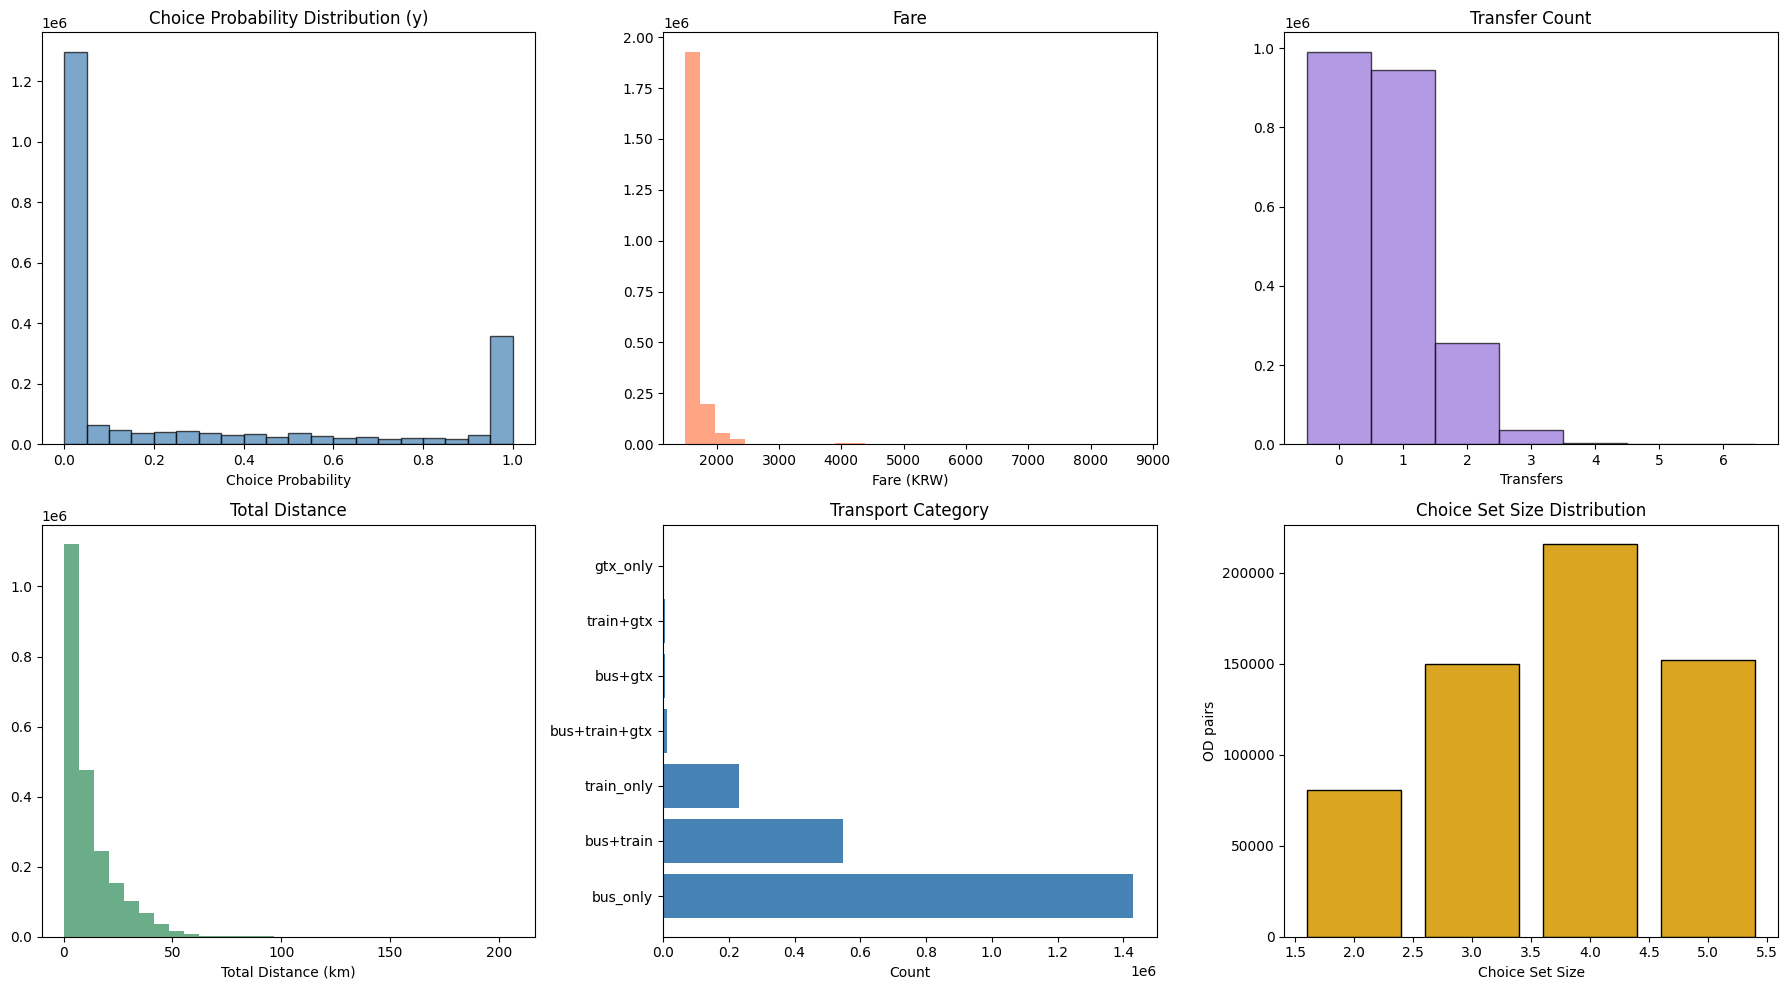

In [8]:
# === 피처 통계 + 시각화 ===
numeric_features = [
    'total_duration', 'in_vehicle_time', 'walk_time', 'wait_time',
    'access_time', 'egress_time', 'transfer_walk_time',
    'walk_distance', 'total_distance', 'bus_distance',
    'subway_distance', 'gtx_distance',
    'num_transfers', 'num_legs', 'fare', 'generalized_cost',
    'od_distance', 'choice_prob',
]

print('=== 수치 피처 통계 ===')
print(agg_df[numeric_features].describe().round(3).to_string())

print(f'\n=== transport_category 분포 ===')
print(agg_df['transport_category'].value_counts().to_string())

# 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(agg_df['choice_prob'], bins=20, alpha=0.7, color='steelblue',
                edgecolor='black')
axes[0, 0].set_xlabel('Choice Probability')
axes[0, 0].set_title('Choice Probability Distribution (y)')

axes[0, 1].hist(agg_df['fare'], bins=30, alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Fare (KRW)')
axes[0, 1].set_title('Fare')

axes[0, 2].hist(agg_df['num_transfers'],
                bins=range(0, agg_df['num_transfers'].max() + 2),
                alpha=0.7, color='mediumpurple', edgecolor='black', align='left')
axes[0, 2].set_xlabel('Transfers')
axes[0, 2].set_title('Transfer Count')

axes[1, 0].hist(agg_df['total_distance'] / 1000, bins=30, alpha=0.7, color='seagreen')
axes[1, 0].set_xlabel('Total Distance (km)')
axes[1, 0].set_title('Total Distance')

cat_counts = agg_df['transport_category'].value_counts()
axes[1, 1].barh(cat_counts.index, cat_counts.values, color='steelblue')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_title('Transport Category')

cs_dist_plot = agg_df.groupby('od_pair')['alt_idx'].count().value_counts().sort_index()
axes[1, 2].bar(cs_dist_plot.index, cs_dist_plot.values,
               color='goldenrod', edgecolor='black')
axes[1, 2].set_xlabel('Choice Set Size')
axes[1, 2].set_ylabel('OD pairs')
axes[1, 2].set_title('Choice Set Size Distribution')

plt.tight_layout()
plt.show()

=== choice_prob과 피처 상관계수 ===
walk_time          -0.404635
num_transfers      -0.234014
generalized_cost   -0.097537
total_duration     -0.083211
wait_time          -0.062287
fare               -0.032096
total_distance     -0.029751
in_vehicle_time     0.005914


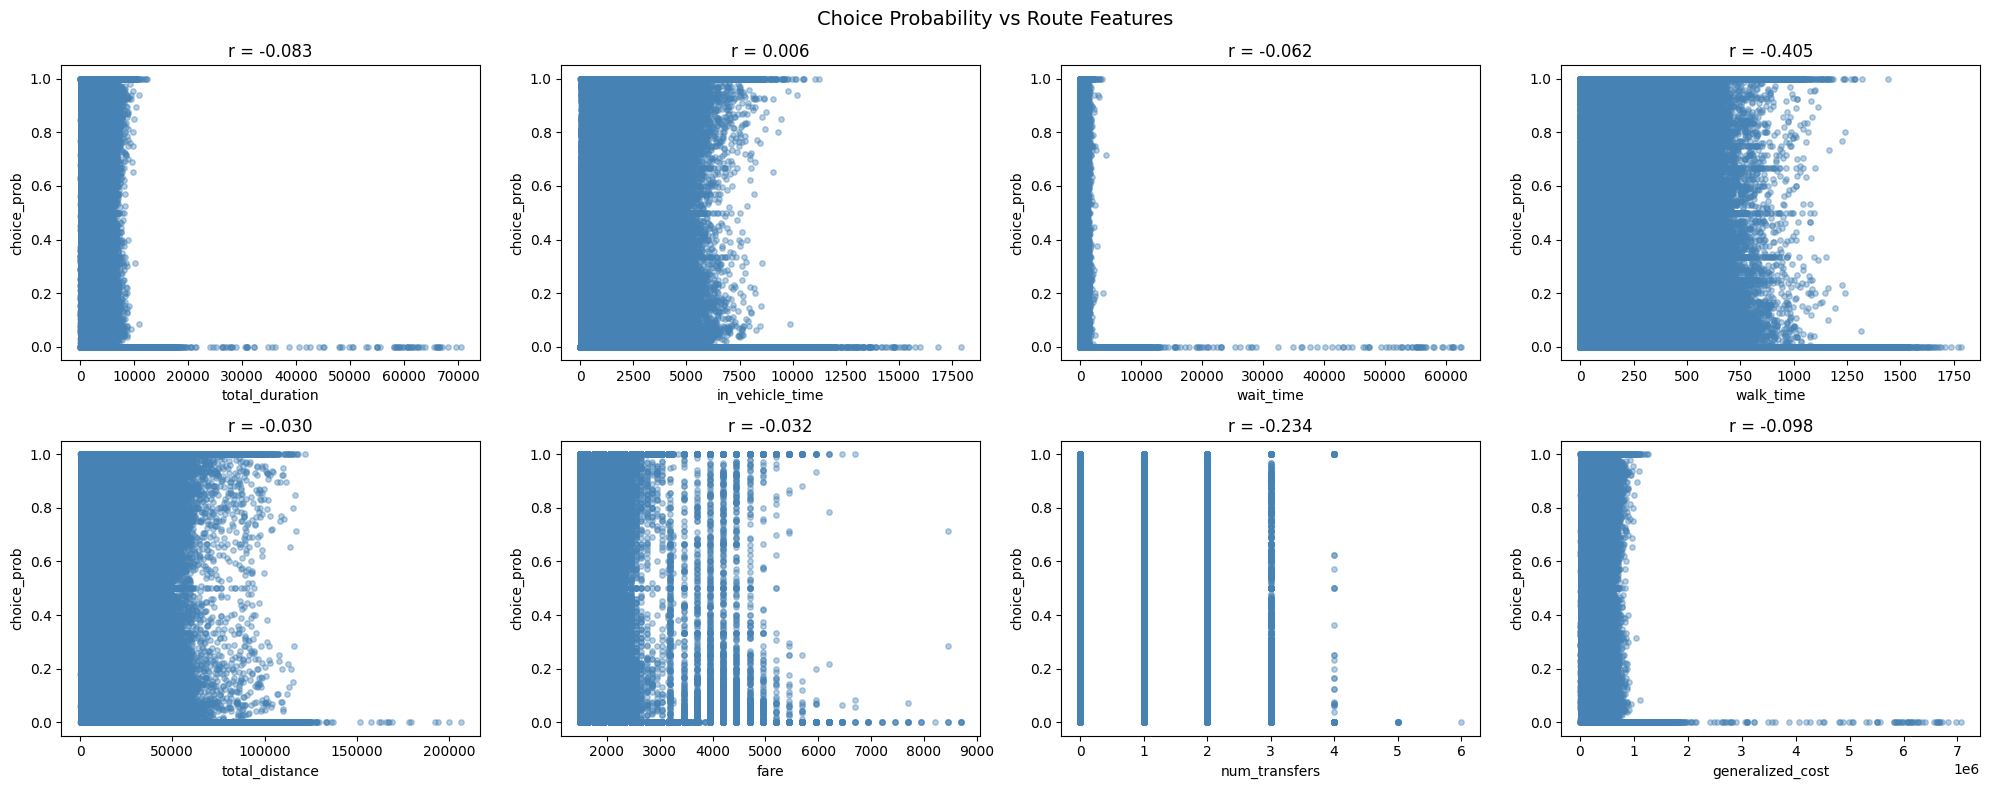


=== transport_category별 평균 choice_prob ===
                    avg_choice_prob  n_alternatives
transport_category                                 
bus_only                      0.261         1429736
bus+train                     0.212          548714
train_only                    0.462          230350
bus+train+gtx                 0.013           10766
bus+gtx                       0.051            6675
train+gtx                     0.204            6538
gtx_only                      0.227              22


In [9]:
# === choice_prob vs 피처 상관관계 ===
compare_features = [
    'total_duration', 'in_vehicle_time', 'wait_time', 'walk_time',
    'total_distance', 'fare', 'num_transfers', 'generalized_cost',
]

print('=== choice_prob과 피처 상관계수 ===')
corr = agg_df[['choice_prob'] + compare_features].corr()['choice_prob'].drop('choice_prob')
print(corr.sort_values().to_string())

# 시각화: 피처별 choice_prob scatter
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for idx, feat in enumerate(compare_features):
    ax = axes[idx]
    ax.scatter(agg_df[feat], agg_df['choice_prob'],
               alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('choice_prob')
    ax.set_title(f'r = {corr[feat]:.3f}')

plt.suptitle('Choice Probability vs Route Features', fontsize=14)
plt.tight_layout()
plt.show()

# transport_category별 평균 선택 확률
print(f'\n=== transport_category별 평균 choice_prob ===')
cat_prob = agg_df.groupby('transport_category')['choice_prob'].agg(['mean', 'count'])
cat_prob.columns = ['avg_choice_prob', 'n_alternatives']
print(cat_prob.sort_values('n_alternatives', ascending=False).round(3).to_string())

In [10]:
# === 최종 저장 ===
PARQUET_PATH = os.path.join(OUTPUT_DIR, 'route_choice_training.parquet')
CSV_PATH = os.path.join(OUTPUT_DIR, 'route_choice_training.csv')

# OD 단위 집계 데이터 저장 (메인 트레이닝셋)
agg_df.to_parquet(PARQUET_PATH, index=False)
agg_df.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')

# 개인 trip 단위 데이터도 보존 (검증/분석용)
INDIVIDUAL_PATH = os.path.join(OUTPUT_DIR, 'route_choice_individual.parquet')
training_df.to_parquet(INDIVIDUAL_PATH, index=False)

# 체크포인트 정리
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, 'training_checkpoint.parquet')
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print('체크포인트 삭제')

print(f'\n=== 저장 완료 ===')
print(f'  [메인] {PARQUET_PATH}')
print(f'    행 수: {len(agg_df):,} (OD × alt)')
print(f'    OD pairs: {agg_df["od_pair"].nunique():,}')
print(f'    컬럼 수: {len(agg_df.columns)}')
print(f'  [개인] {INDIVIDUAL_PATH}')
print(f'    행 수: {len(training_df):,} (trip × alt)')

print(f'\n=== 메인 트레이닝셋 컬럼 ===')
for col in agg_df.columns:
    print(f'  - {col}: {agg_df[col].dtype}')


=== 저장 완료 ===
  [메인] ../data/training_set\route_choice_training.parquet
    행 수: 2,232,801 (OD × alt)
    OD pairs: 597,932
    컬럼 수: 34
  [개인] ../data/training_set\route_choice_individual.parquet
    행 수: 134,829,092 (trip × alt)

=== 메인 트레이닝셋 컬럼 ===
  - od_pair: object
  - alt_idx: int64
  - choice_set_size: int64
  - total_duration: float64
  - in_vehicle_time: float64
  - walk_time: float64
  - wait_time: float64
  - access_time: float64
  - egress_time: float64
  - transfer_walk_time: float64
  - walk_distance: float64
  - total_distance: float64
  - bus_distance: float64
  - subway_distance: float64
  - gtx_distance: float64
  - num_transfers: int64
  - num_legs: int64
  - fare: int64
  - generalized_cost: float64
  - transport_category: object
  - has_bus: int64
  - has_train: int64
  - has_gtx: int64
  - main_route: object
  - n_matched: int32
  - n_total: int64
  - od_distance: float64
  - choice_prob: float64
  - sim_composite: float64
  - sim_mode: float64
  - sim_sequence:

In [11]:
agg_df

,od_pair,alt_idx,choice_set_size,total_duration,in_vehicle_time,walk_time,wait_time,access_time,egress_time,transfer_walk_time,...,n_matched,n_total,od_distance,choice_prob,sim_composite,sim_mode,sim_sequence,sim_time,sim_route,sim_spatial
0,10003_10661,0,3,3087.0,3029.0,8.0,50.0,7.0,1.0,0.0,...,13,13,13022.0,1.0,0.984038,1.0,1.000000,0.920669,1.00000,0.999200
1,10003_10661,1,3,1868.0,1202.0,433.0,233.0,272.0,1.0,160.0,...,0,13,13022.0,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000
2,10003_10661,2,3,1949.0,1202.0,433.0,314.0,272.0,1.0,160.0,...,0,13,13022.0,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000
3,10003_10700,0,3,2842.0,2790.0,14.0,38.0,7.0,7.0,0.0,...,16,16,11710.7,1.0,0.978500,1.0,0.979169,0.966106,0.96875,0.988287
4,10003_10700,1,3,1673.0,986.0,439.0,248.0,272.0,7.0,160.0,...,0,16,11710.7,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232796,9999_9695,1,4,848.0,239.0,569.0,40.0,352.0,217.0,0.0,...,0,64,1643.5,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000
2232797,9999_9695,2,4,848.0,239.0,569.0,40.0,352.0,217.0,0.0,...,0,64,1643.5,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000
2232798,9999_9695,3,4,796.0,334.0,289.0,173.0,1.0,217.0,71.0,...,0,64,1643.5,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000
2232799,9999_9871,0,2,339.0,200.0,99.0,40.0,1.0,98.0,0.0,...,74,74,906.4,1.0,0.963577,1.0,1.000000,0.819803,1.00000,0.996100


In [12]:
training_df

,trip_id,od_pair,alt_idx,choice_set_size,total_duration,in_vehicle_time,walk_time,wait_time,access_time,egress_time,...,departure_dow,is_peak,sc_transport_category,chosen,sim_composite,sim_mode,sim_sequence,sim_time,sim_route,sim_spatial
0,10003_10661_20250217_0,10003_10661,0,3,3087.0,3029.0,8.0,50.0,7.0,1.0,...,0,0,bus_only,1,0.9847,1.0,1.0000,0.9237,1.0000,0.9992
1,10003_10661_20250217_0,10003_10661,1,3,1868.0,1202.0,433.0,233.0,272.0,1.0,...,0,0,bus_only,0,0.3934,0.5,0.5000,0.5589,0.0000,0.8166
2,10003_10661_20250217_0,10003_10661,2,3,1949.0,1202.0,433.0,314.0,272.0,1.0,...,0,0,bus_only,0,0.3983,0.5,0.5000,0.5832,0.0000,0.8166
3,10003_10700_20250217_1,10003_10700,0,3,2842.0,2790.0,14.0,38.0,7.0,7.0,...,0,0,bus_only,1,0.7655,1.0,0.6667,0.9923,0.5000,0.8366
4,10003_10700_20250217_1,10003_10700,1,3,1673.0,986.0,439.0,248.0,272.0,7.0,...,0,0,bus_only,0,0.4891,0.5,0.5000,0.5841,0.3333,0.7230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134829087,9999_9871_20250223_38662356,9999_9871,1,2,536.0,185.0,311.0,40.0,1.0,310.0,...,0,0,bus_only,0,0.5157,1.0,0.5000,0.5896,0.0000,0.9780
134829088,9999_9871_20250223_38662357,9999_9871,0,2,339.0,200.0,99.0,40.0,1.0,98.0,...,0,0,bus_only,1,0.9713,1.0,1.0000,0.8584,1.0000,0.9961
134829089,9999_9871_20250223_38662357,9999_9871,1,2,536.0,185.0,311.0,40.0,1.0,310.0,...,0,0,bus_only,0,0.5064,1.0,0.5000,0.5429,0.0000,0.9780
134829090,9999_9871_20250223_38662358,9999_9871,0,2,339.0,200.0,99.0,40.0,1.0,98.0,...,0,0,bus_only,1,0.9869,1.0,1.0000,0.9365,1.0000,0.9961
